# Dance Quality Assessment

**Intern Take-Home Assignment**

Build a pipeline that analyzes a 1-minute dance video and produces a quality score (0–100).

Read `README.md` for full instructions and `RUBRIC.md` for how you'll be evaluated.

---
## 0. Setup & Configuration

In [13]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

VIDEO_PATH = Path("data/dance_video.mp4")  # <- update if your file is named differently
assert VIDEO_PATH.exists(), f"Video not found at {VIDEO_PATH}. Place your dance video there."

cap = cv.VideoCapture(str(VIDEO_PATH))
FPS = cap.get(cv.CAP_PROP_FPS)
FRAME_COUNT = int(cap.get(cv.CAP_PROP_FRAME_COUNT))
DURATION = FRAME_COUNT / FPS
cap.release()

print(f"Video: {VIDEO_PATH.name}")
print(f"FPS: {FPS:.1f} | Frames: {FRAME_COUNT} | Duration: {DURATION:.1f}s")

Video: dance_video.mp4
FPS: 59.6 | Frames: 3627 | Duration: 60.9s


---
## 1. Pose Estimation

Extract body keypoints from every frame (or a sampled subset).

**Suggested tools:** MediaPipe Pose, OpenPose, MMPose, or any pretrained model.

Your output should be an array of shape `(num_frames, num_keypoints, 2 or 3)` containing (x, y) or (x, y, confidence) per keypoint per frame.

In [14]:
import mediapipe as mp

mp_pose = mp.solutions.pose
pose = mp_pose.Pose(static_image_mode=False, min_detection_confidence=0.5)
all_keypoints = []

# Load video
cap = cv.VideoCapture(str(VIDEO_PATH))
if not cap.isOpened():
    print("Cannot load Video")
    exit()
while cap.isOpened():
   # Capture frame-by-frame
    success, frame = cap.read()
    if not success:
        print("End of video or failed frame")
        break
    # width and height 
    frame_height, frame_width, _ = frame.shape
    # Convert the BGR image to RGB before processing
    rgb_frame = cv.cvtColor(frame, cv.COLOR_BGR2RGB)
    results = pose.process(rgb_frame)
    # Extract and Store Keypoints
    if results.pose_landmarks:
        frame_keypoints = []
        for landmark in results.pose_landmarks.landmark:
            frame_keypoints.append([landmark.x, landmark.y])
        all_keypoints.append(frame_keypoints)
    cv.imshow('Dance', frame)
    # press 'q' to quit the frame
    if cv.waitKey(1) == ord('q'):
        print("Exited video")
        break
# clean up after end of video
cap.release()
cv.destroyAllWindows()
cv.waitKey(1)
keypoints = np.array(all_keypoints)
print(f"Keypoints shape: {keypoints.shape}")

I0000 00:00:1773197834.035602 7112135 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M1
W0000 00:00:1773197834.157701 7117451 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773197834.174918 7117451 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Exited video
Keypoints shape: (28, 33, 2)


---
## 2. Quality Dimensions

Implement **at least 3** quality dimensions from the table in `README.md`.

1. Compute a raw signal or metric from the keypoints.
2. Normalize it to a 0–100 sub-score.
3. Briefly explain your approach in a markdown cell.

### 2a. Dimension 1: Pose stability

1. Create sliding windows that each one of size 5 frames.
2. For each sliding window, calculate the variance for each keypoint.
variance formula: 
Var = 1/total_num_keypoints * ∑ (keypoint - mean_keypoint)^2
3. Then move the start of the next sliding window by 1 index and repeat.
4. Calculate the avarage of all results to get the score for the video.
5. Reverse min-max normalization for score: dim1_score = (1 - (score - min)/(max - min))*100


In [15]:
frames_num = keypoints.shape[0]
scores = []
raw_signal = 0
frames_in_sliding_window = 5
keypoints_per_frame = keypoints.shape[1]
keypoints_in_sliding_window = frames_in_sliding_window * keypoints_per_frame
sliding_window_start = 0
while sliding_window_start + frames_in_sliding_window <= frames_num:
    sliding_window_indices = keypoints[sliding_window_start: sliding_window_start + frames_in_sliding_window]
    mean_keypoint_in_sliding_window = np.mean(sliding_window_indices, axis=(0,1))
    varx_y = 0
    # for each frame in sliding window, sum all keypoints
    for frame in sliding_window_indices:
        for keypoint in frame:
            varx_y += np.square(keypoint - mean_keypoint_in_sliding_window)
    var =  np.sum(varx_y)
    if keypoints_in_sliding_window > 0:
        raw_signal = (1 / keypoints_in_sliding_window) * var
    # normalize
    scores.append(raw_signal)
    # move one frame to create next sliding window
    sliding_window_start += 1
# calculate the avarage and normalize score
# lower score is better
score = np.mean(scores)
min_val = np.min(scores)
max_val = np.max(scores)
if max_val != min_val:
    dim1_score = (1 - (score - min_val)/(max_val - min_val)) * 100
else:
    dim1_score = 100
print(f"dim1_score: {dim1_score}")    

dim1_score: 40.468393840625694


### 2b. Dimension 2: Symmetry

1. Extract mirrored body parts from the body keypoints
2. Calculate the distance between each side and the center of the body
3. Calculate the difference between the sides
4. Normalize the symmetry score: dim2_score = 100 / (1 + score)

In [16]:
LEFT_SHOULDER = 11
RIGHT_SHOULDER = 12
LEFT_ELBOW = 13
RIGHT_ELBOW = 14
LEFT_WRIST = 15
RIGHT_WRIST = 16
LEFT_HIP = 23
RIGHT_HIP = 24
LEFT_KNEE = 25
RIGHT_KNEE = 26
LEFT_ANKLE = 27
RIGHT_ANKLE = 28
LEFT_FOOT = 31
RIGHT_FOOT = 32
symmetry = []
bodyparts = [LEFT_SHOULDER, LEFT_ELBOW, LEFT_WRIST, LEFT_KNEE,RIGHT_KNEE, LEFT_ANKLE, LEFT_FOOT]
for body in keypoints:
    symmetry_per_frame = []
    # center between the two hips
    body_center = (body[LEFT_HIP] + body[RIGHT_HIP]) / 2
    for bodypart in bodyparts:
        # distance between body part and center
        # then diffrence between two sides
        distanse_with_center = np.abs(np.linalg.norm(body[bodypart] - body_center) - np.linalg.norm(body[bodypart + 1] - body_center))
        # skip when the body part is not detected
        if not np.isnan(distanse_with_center):
            symmetry_per_frame.append(distanse_with_center)
    if len(symmetry_per_frame) > 0:
        # avarage of symmetry in the frame
        avg_per_frame = np.mean(symmetry_per_frame)
        symmetry.append(avg_per_frame)
# avarage across frames and normalize score
# lower score is better  
score = np.mean(symmetry)
dim2_score = 100 / (score + 1)
print(f"dim2_score: {dim2_score}")    

dim2_score: 91.50432296083189


### 2c. Dimension 3: Spatial coverage

1. for each frame extract and normalize the nose, shoulders, wrists, hips and feet
2. then from all of these points create a convex hull and calculate the area it is covering (= the area the dancer covered during the dance)
3. calculate the score, divide that area by the maximum possible area of the frame and scale to 100

In [17]:
NOSE = 0
movement = []
max_possible_area = frame_width * frame_height
for body in keypoints:
    # normlize it to pixels
    body_left_hip = body[LEFT_HIP] * np.array([frame_width, frame_height])
    body_right_hip = body[RIGHT_HIP] * np.array([frame_width, frame_height])
    body_left_foot = body[LEFT_FOOT] * np.array([frame_width, frame_height])
    body_right_foot = body[RIGHT_FOOT] * np.array([frame_width, frame_height])
    body_left_shoulder = body[LEFT_SHOULDER] * np.array([frame_width, frame_height])
    body_right_shoulder = body[RIGHT_SHOULDER] * np.array([frame_width, frame_height])
    body_nose = body[NOSE] * np.array([frame_width, frame_height])
    body_left_wrist = body[LEFT_WRIST] * np.array([frame_width, frame_height])
    body_right_wrist = body[RIGHT_WRIST] * np.array([frame_width, frame_height])
    movement.append(body_left_hip)
    movement.append(body_right_hip)
    movement.append(body_left_foot)
    movement.append(body_right_foot)
    movement.append(body_left_shoulder)
    movement.append(body_right_shoulder)
    movement.append(body_nose)
    movement.append(body_left_wrist)
    movement.append(body_right_wrist)
movement = np.array(movement, dtype=np.float32)
hull = cv.convexHull(movement)
area = cv.contourArea(hull)  
# higher area is better
dim3_score = (area / max_possible_area) * 100
print(f"dim3_score: {dim3_score}")    

dim3_score: 26.94549937125189


---
## 3. Final Score

Combine your sub-scores into one overall quality score (0–100).

The score of the pose stability is the most important one, because it is a strong indicator for how well the dancers can control their bodies during the dance.
Next is symmetry which is also related to the technique of the dancers, but at the end, during the dance they move a lot and they are not robots so it is hard to "calculate" the correct distances between the left and right body parts in real time during the dance, so this score got a bit lower weight.
Finally, the spatial coverage got the lowest weight. This measurement depends not only on the dencer's moves but also on how the video was taken and the use of zoom-ins.


In [18]:
weights = {"dim1": 0.5, "dim2": 0.35, "dim3": 0.15}
final_score = weights["dim1"] * dim1_score + weights["dim2"] * dim2_score + weights["dim3"] * dim3_score
print(f"\n{'='*40}")
print(f"  DANCE QUALITY SCORE: {final_score:.1f} / 100")
print(f"{'='*40}")


  DANCE QUALITY SCORE: 56.3 / 100


---
## 4. Visualization

Include **at least 2** visualizations. Ideas:
- Pose keypoints overlaid on sample frames
- A quality signal plotted over time
- Sub-score breakdown bar chart
- Heatmap of movement intensity

In [19]:
# Visualization 1
# Pose keypoints overlaid on sample frames

PINK = (255, 0, 255)
WHITE = (255, 255, 255)

mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

# Load video
cap = cv.VideoCapture(str(VIDEO_PATH))
if not cap.isOpened():
    print("Cannot load Video")
    exit()
while cap.isOpened():
   # Capture frame-by-frame
    success, frame = cap.read()
    if not success:
        print("End of video or failed frame")
        break
    # Convert the BGR image to RGB before processing
    rgb_frame = cv.cvtColor(frame, cv.COLOR_BGR2RGB)
    results = pose.process(rgb_frame)
    # draw the pose overlaid
    if results.pose_landmarks:
            mp_drawing.draw_landmarks(
            frame,
            results.pose_landmarks,
            mp_pose.POSE_CONNECTIONS,
            mp_drawing_styles.DrawingSpec(circle_radius = 3, color = WHITE, thickness = 0),
            mp_drawing.DrawingSpec(color= PINK, thickness = 3))  

    cv.imshow('Dance Pose', frame)
    # press 'q' to quit the frame
    if cv.waitKey(1) == ord('q'):
        print("Exited video")
        break

# clean up after end of video
cap.release()
cv.destroyAllWindows()
cv.waitKey(1)

Exited video


-1

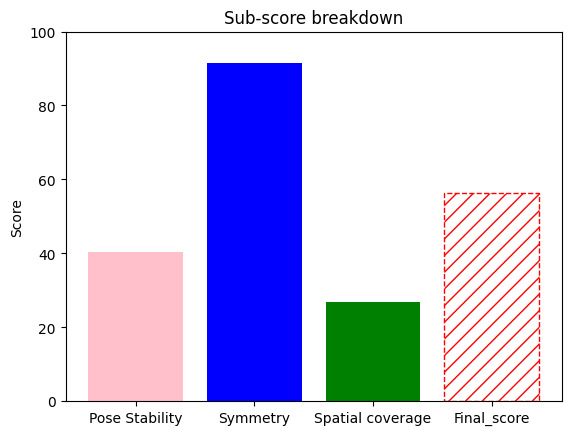

In [20]:
# Visualization 2
# Sub-score breakdown bar chart + final score

scores = [dim1_score, dim2_score, dim3_score, final_score]
labels = ['Pose Stability', 'Symmetry', 'Spatial coverage', 'Final_score']
colors = ['pink', 'blue', 'green']
bars = plt.bar(labels, scores, color = colors)
# Make the final score bar visually distinct
bars[-1].set_facecolor('none') 
bars[-1].set_edgecolor('red')  
bars[-1].set_hatch('//')  
bars[-1].set_linestyle('--')
plt.ylim(0, 100) 
plt.title("Sub-score breakdown")
plt.ylabel("Score")
plt.show()

---
## 5. Discussion

Answer briefly (2–4 sentences each):

1. **What are the biggest limitations of your approach?**

3. **If you had another week, what would you improve?**

4. **How would you validate that your score correlates with actual dance quality?**

**Answers:**

1. Right now, the video plays in slow motion. I think it is becuse there is a lot of information to analayze, process and calculate per frame, and it takes more time.
2. If I had more time I would probably implement more of the suggested features and update the current ones. For example, I would add a live score display during the video, with the distribution chart overlaid in realtime. Instead of only outputting the chart when all the scores are finalized.
3. I will use shorter videos and watch them. Then I will assign appropriate scores based on the criteria I used for the program and write them down. After that I'll run the program with the same videos and will compare the output with the scores I came up with prior to running the program.